<div style="width:100%; background-color:181818; color:f1f1f1; padding:30px 0; text-align:center; border-radius:10px;">

  <img src="https://media4.giphy.com/media/v1.Y2lkPTc5MGI3NjExOWI5emc0dnp2Z24ycDJibGkxbmM1ZjU2aDdqaW5yODdic3JzZjMxcyZlcD12MV9naWZzX3NlYXJjaCZjdD1n/1gXg8Hrjah7bmm45W7/giphy.webp" alt="Eigen" width="500" style="border-radius:10px;">

  <h3 style="color:ffffff; margin-top:15px;"><b>Examples of Solution Eigen values & Eigen Vectors</b></h3>

  <p><b>Author:</b> <a href="http://caceli.net/" style="color:3ea6ff; text-decoration:none;">Msc. Ing. Carlos Andrés Celi Sánchez</a></p>
  <p><b>Course:</b> Seismic Desing</p>
  <p><b>Year:</b> MARCH - 2026</p>

</div>

### Libraries

In [1]:
import sys
import os
import glob
from pathlib import Path
sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
from numpy.linalg import eig, inv  
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from repo_seismic_desing import *

## Example
![alt text](image-10.png)

#### Data

In [3]:
ProjecName = 'Edifico Rivadavia'

h = 3.60                                                                                                                        # Height of a single floor [m]
sto = 5                                                                                                                         # Number of floors
H = np.ones(sto) * h                                                                                                            # Vector containing the heights of all floors [m]
span = [3,3]                                                                                                                    # Number of spans in x and y directions
LVx = 30/5                                                                                                                          # longitud de vanos (se emplea unicamente para graficar)
LVy = 40/5
LV = LVx
Afloor = (span[0] * LVx) * (span[1] * LVy)
WD = 0.25
WL = 0.20
Wpp = 1.18
wpi = Afloor * (1.0* WD + 1.0 * WL + 1.0 * Wpp) 
E = 2000000                                                                                                                     # Elastic modulus in [T/m^2]
u = 0.2                                                                                                                         # Poisson's ratio of the material (dimensionless).
G = E / (2*(1 + u))                                                                                                             # Shear modulus calculated using the relationship between E and u [T/m^2].
f = 1/5                                                                                                                         # shape factor
C = 0.4                                                                                                                        # Size of the column in [m] (Square Columns)
iner = C**4 / 12                                                                                                                # Moment of inertia of columns [m^4]
A = C * C                                                                                                                       # Area [m^2]
facIene = 0.80
INERs = np.ones(sto) * iner * facIene                                                                                           # Vector containing the inertia of columns per floor [m^4]
iner = iner * facIene
g = 9.8                                                                                                                         # Gravitational acceleration [m/s^2]
MPall = np.ones(sto) * (wpi / g)                                                                                                # Vector containing the mass of each floor [T·s^2/m]
maxdrift = 1.50                                                                                                                 # Define maximum allowed drift percentage
fss = 1.5                                                                                                                        # factor de escala para dibujo de columnas y vigas
C = C * fss                                                                                                                      # tamaño de columnas y vigas para dibujo


#----------City---------
city = 'Pichincha - Quito - Cumbaya'
#---------Soild type--------
suelo = 'C'
#--------- PGA TR475 --------
z = 0.47
#--------- Amplification Soild Factors -------
zone = 'III'
fads = [1.19, 1.08, 1.17]
rr = 1
R = 7
I = 1.25

#------- Colocation r -------
r = np.ones(len(H))


# Display results for verification
print('\x1b[1;34m')
print("="*120)
print('\x1b[1;34m  Floor Weigth:', wpi)
print('\x1b[1;34m  Vector of floor heights (H):', H)
print('\x1b[1;34m  Vector of column inertias (INERs):', INERs)
print('\x1b[1;34m  Vector of floor masses (MPall):', MPall)
print('\x1b[1;34m  Vector of r:', r)
print("="*120)


  Floor Weigth: 704.16
  Vector of floor heights (H): [3.6 3.6 3.6 3.6 3.6]
  Vector of column inertias (INERs): [0.00170667 0.00170667 0.00170667 0.00170667 0.00170667]
  Vector of floor masses (MPall): [71.85306122 71.85306122 71.85306122 71.85306122 71.85306122]
  Vector of r: [1. 1. 1. 1. 1.]


#### Stiffness Matrix for each Floor

In [4]:
Kfloor = Assamble_K_M(span=span,iner= iner,H=H,E=E,G=G,f=f,A=A, Mall= MPall)
k = Kfloor.kfloor()
k_frame = pd.DataFrame(k, columns=['Stiffness Vector'])                                                                        # Create a DataFrame from the stiffness vector
k_frame.head(len(k))

number of columns per floor =  16


,Stiffness Vector
0,13980.36196
1,13980.36196
2,13980.36196
3,13980.36196
4,13980.36196


#### Structure Stiffness Matrix

In [5]:
K = Kfloor.matrixK(k)
K_frame = pd.DataFrame(K, columns=[f'Column {i+1}' for i in range(K.shape[1])])                                                 # Convert K (2D array) into a DataFrame with column names based on the number of columns                    
K_frame.head(len(k))

,Column 1,Column 2,Column 3,Column 4,Column 5
0,27960.723921,-13980.361960,0.000000,0.000000,0.00000
1,-13980.361960,27960.723921,-13980.361960,0.000000,0.00000
2,0.000000,-13980.361960,27960.723921,-13980.361960,0.00000
3,0.000000,0.000000,-13980.361960,27960.723921,-13980.36196
4,0.000000,0.000000,0.000000,-13980.361960,13980.36196


#### Structure Mass Matrix

In [6]:
M = Kfloor.matrixM()
M_frame = pd.DataFrame(M, columns=[f'Mass {i+1}' for i in range(M.shape[1])])                                                    # Convert the diagonal matrix to a DataFrame with appropriate column names
M_frame.head(len(M))

,Mass 1,Mass 2,Mass 3,Mass 4,Mass 5
0,71.853061,0.000000,0.000000,0.000000,0.000000
1,0.000000,71.853061,0.000000,0.000000,0.000000
2,0.000000,0.000000,71.853061,0.000000,0.000000
3,0.000000,0.000000,0.000000,71.853061,0.000000
4,0.000000,0.000000,0.000000,0.000000,71.853061


#### Solution Eigen Values and Eigen Vectors

In [7]:
Eigen = Eig_Normalize(K = K, M = M)
w2, v, a = Eigen.eigen()
idx = np.argsort(w2)                                                                                                             # Sort eigenvalues in ascending order
w2 = w2[idx]                                                                                                                     # Reorganize eigenvalues
w = np.sqrt(w2)                                                                                                                  # Compute the natural angular frequencies w = sqrt(w2)
T = 2 * np.pi / w                                                                                                                # Compute the periods T = 2 * pi / w
f = 1 / T                                                                                                                        # Compute the natural frequencies f = 1 / T
v = v[:, idx]                                                                                                                    # Reorganize eigenvectors according to sorted eigenvalues
v_normalized = Eigen.normalize_modes(v)                                                                                          # Normalize the mode shapes using the mass matrix

# Combine the results into a DataFrame
Resul_frame = pd.DataFrame({
    'Angular Frequencies': w,                                                                                                    # Column for angular frequencies w
    'Periods [s]': T,                                                                                                            # Column for periods T
    'Frequencies [Hz]': f                                                                                                        # Column for frequencies f
})

# Add normalized mode shapes to the DataFrame
for i in range(v_normalized.shape[1]):                                                                                           # Loop through each normalized mode shape
    Resul_frame[f'Normalized Mode {i+1}'] = v_normalized[:, i]                                                                   # Add each normalized mode shape as a separate column

Resul_frame.head(len(T))

,Angular Frequencies,Periods [s],Frequencies [Hz],Normalized Mode 1,Normalized Mode 2,Normalized Mode 3,Normalized Mode 4,Normalized Mode 5
0,3.970240,1.582571,0.631883,0.020042,-0.053764,0.070415,0.064711,0.038461
1,11.589074,0.542165,1.844458,0.038461,-0.070415,0.020042,-0.053764,-0.064711
2,18.269031,0.343925,2.907607,0.053764,-0.038461,-0.064711,-0.020042,0.070415
3,23.468940,0.267723,3.735198,0.064711,0.020042,-0.038461,0.070415,-0.053764
4,26.767534,0.234732,4.260185,0.070415,0.064711,0.053764,-0.038461,0.020042


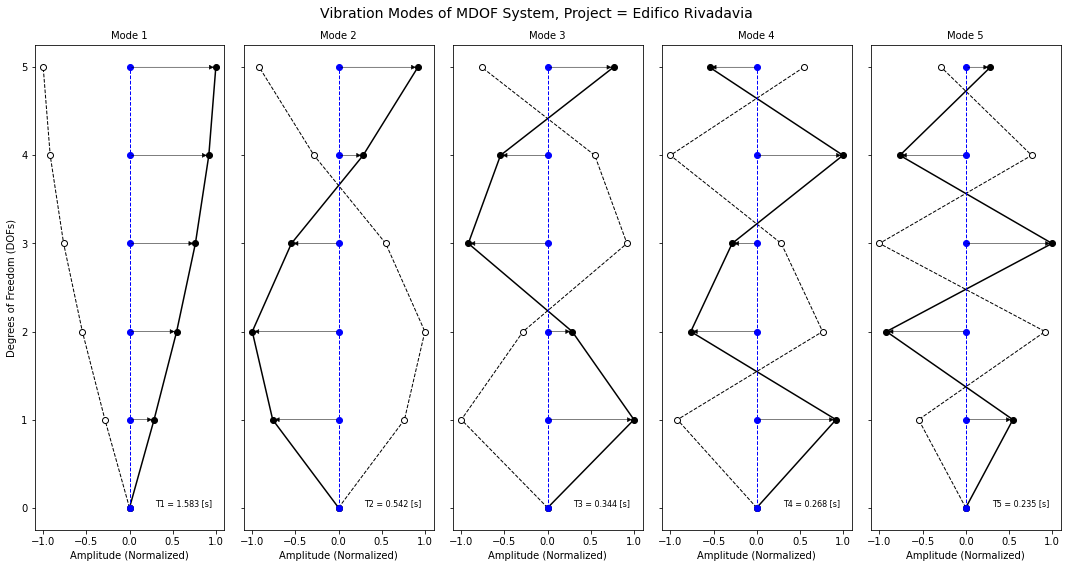

In [8]:
plotvibration = Plot_vibration(v = v_normalized,num_modes_to_plot= len(T), T = T, plotmax= 5, project= ProjecName)
plotvibration.plot_vibration_modes_subplots()

#### Calculate the modal excitation factor for each structural period (**$\{L\}$**).

$$ \{L\} = [\mathbf{\Phi}_n]^\mathrm{T} [M] \{r\} $$


In [9]:
L = np.dot(np.dot(v_normalized.T, M), r)                                                                                          # Calculation of the modal excitation factor vector {L} using the formula {L} = [Φ_n]^T [M] {r}.
L_frame = pd.DataFrame(L, columns= ['Modal excitation factor'])                                                                   # Convert the modal excitation factor vector {L} into a DataFrame for better visualization.
L_frame.head(len(L)) 

,Modal excitation factor
0,17.775956
1,-5.596414
2,2.949547
3,1.642511
4,0.750450


#### Effective Modal Mass.

$$ 
   \{M_{e,i}\} = \frac{\{L_i\}^2}{\sum M_{\text{total}}} 
   $$

In [10]:
Mtotal = np.sum(np.diag(M))                                                                                                       # Calculate the total mass by summing the diagonal elements of the mass matrix M
M_e = []                                                                                                                          # Initialize a list to store the effective modal masses

for i in np.arange(0, len(T), 1):                                                                                                 # Iterate through each mode
    M_e.append(L[i]**2 / Mtotal * 100)                                                                                            # Calculate the effective modal mass for each mode and append to the list in "%"

M_e_frame = pd.DataFrame(M_e, columns= ['Effective Modal Mass [%]'])                                                              # Create a DataFrame from the effective modal mass array
M_e_frame.head(len(M_e))                                                                                                          # Display the DataFrame with effective modal masses

,Effective Modal Mass [%]
0,87.953000
1,8.717750
2,2.421560
3,0.750933
4,0.156757


#### Cumulative Effective Mass.

$$ 
   \{M_{e,\text{cumulative}}\} = \sum_{i=1}^{N} \{M_{e,i}\} 
   $$

In [11]:
M_e_acum = np.zeros(len(M_e))                                                                                                     # Initialize an array of zeros to store the cumulative effective modal masses
M_e_acum[0] = M_e[0]                                                                                                              # Set the first element of the cumulative array to the first effective modal mass

for i in np.arange(1, len(M_e), 1):                                                                                               # Loop through the remaining effective modal masses
    M_e_acum[i] = M_e_acum[i - 1] + M_e[i]                                                                                        # Add the current effective modal mass to the cumulative total

M_e_acum_frame = pd.DataFrame(M_e_acum, columns= ['Cumulative Effective Mass [%]'])                                               # Create a DataFrame from the cumulative effective modal mass array
M_e_acum_frame.head(len(M_e_acum))                                                                                                # Display the DataFrame with cumulative effective modal masses

,Cumulative Effective Mass [%]
0,87.953000
1,96.670750
2,99.092310
3,99.843243
4,100.000000


#### Spectral Analisys

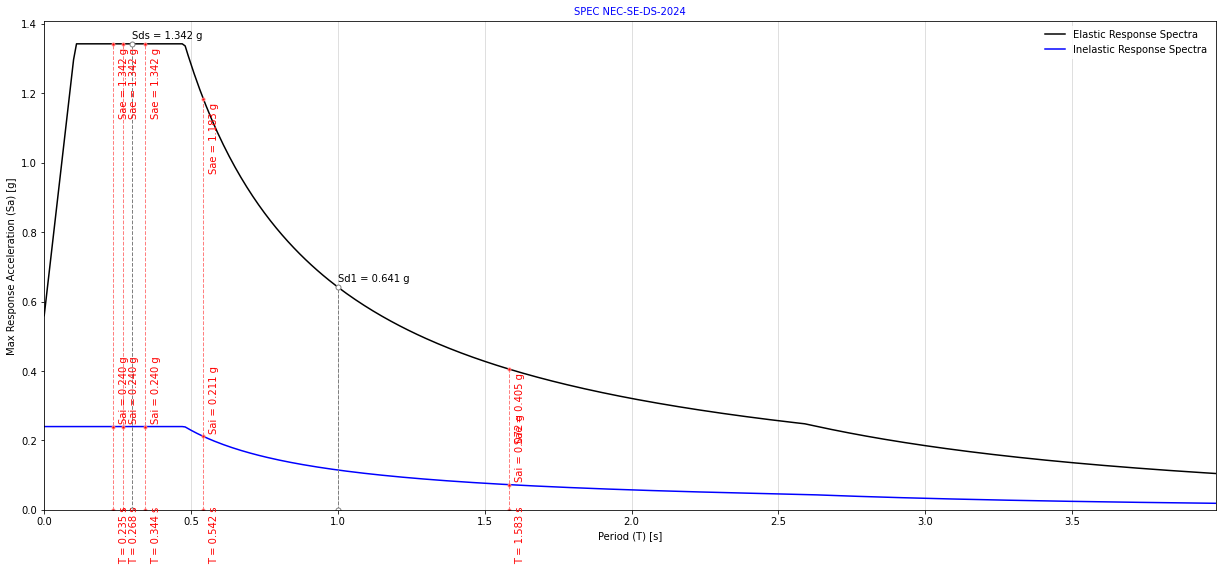

,Period [s],Sae [g],Sai [g]
0,1.582571,0.405292,0.072374
1,0.542165,1.183042,0.211257
2,0.343925,1.342320,0.239700
3,0.267723,1.342320,0.239700
4,0.234732,1.342320,0.239700


In [12]:
Spec = SpecNec2024_Sae_Sai_modal(Tfind = T, fads = fads, I = I, z = z, n = 2.4, R = R, r = rr, Tf = 4, dT = 0.01)
Resul, SaeF, SaiF, Tl, Sds, Sd1, Sae, Sai, Tie  = Spec.plot_SpecNEC_modal()
Resul

In [25]:
Tie

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99, 1.  , 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09,
       1.1 , 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17, 1.18, 1.19, 1.2 ,
       1.21, 1.22, 1.23, 1.24, 1.25, 1.26, 1.27, 1.28, 1.29, 1.3 , 1.31,
       1.32, 1.33, 1.34, 1.35, 1.36, 1.37, 1.38, 1.39, 1.4 , 1.41, 1.42,
       1.43, 1.44, 1.45, 1.46, 1.47, 1.48, 1.49, 1.

#### Calculate the maximum modal displacement ($ q_n^{\mathrm{max}} $) and the maximum modal lateral force ($ Q_n^{\mathrm{max}} $) for each mode.

   $$ \{q_n^{\mathrm{max}}\} = \frac{L_n \cdot S_{ai,n} \cdot g }{\omega_n^2} \cdot \{\mathbf{\Phi}_n\} $$

   $$ \{Q_n^{\mathrm{max}}\} = L_n \cdot S_{ai,n} \cdot g \cdot [M] \cdot \{\mathbf{\Phi}_n\} $$

In [13]:
qn = []                                                                                                                          # Initialize a list to store the maximum modal displacements
Qn = []                                                                                                                          # Initialize a list to store the maximum modal lateral force
g = 9.8                                                                                                                          # Gravitational acceleration in m/s^2

Cd = 5.5                                                                                                                         # Inelastic displacement amplification factor based on the response modification coefficient (R)

for i in np.arange(0, len(M_e_acum), 1):                                                                                         # Loop through the modes to calculate the maximum modal displacement
    qn.append(((L[i] * SaiF[i] * g )/ (w2[i])) * v_normalized[:, i] * Cd)                                                        # Calculate and append the maximum modal displacement for each mode
    Qn.append(L[i] * SaiF[i] * g * np.dot(M, v_normalized[:, i]))                                                                # Calculate and append the maximum modal lateral force for each mode

qn_array = np.array(qn).T                                                                                                        # Convert the list to a NumPy array and transpose for column-wise representation
Qn_array = np.array(Qn).T                                                                                                        # Convert the list to a NumPy array and transpose for column-wise representation


qn_columns = [f'qn{i + 1}' for i in range(qn_array.shape[1])]                                                                    # Generate column names as qn1, qn2, ..., qnN
Qn_columns = [f'Qn{i + 1}' for i in range(qn_array.shape[1])]                                                                    # Generate column names as qn1, qn2, ..., qnN

rows = pd.Index(f'd{i + 1}' for i in range(len(T)))

qn_frame = pd.DataFrame(qn_array, columns=qn_columns, index = rows)                                                              # Create a DataFrame with appropriate column names
qn_frame.head(len(qn))                                                                                                           # Display the DataFrame with all modal displacements

,qn1,qn2,qn3,qn4,qn5
d1,0.088169,0.025510,0.008040,0.002493,0.000520
d2,0.169195,0.033410,0.002288,-0.002071,-0.000876
d3,0.236514,0.018249,-0.007389,-0.000772,0.000953
d4,0.284672,-0.009510,-0.004391,0.002713,-0.000728
d5,0.309768,-0.030704,0.006139,-0.001482,0.000271


In [14]:
Qn_frame = pd.DataFrame(Qn_array, columns=Qn_columns, index = rows)                                         # Create a DataFrame with appropriate column names
Qn_frame.head(len(Qn))  

,Qn1,Qn2,Qn3,Qn4,Qn5
d1,18.156513,44.759188,35.056012,17.940079,4.871703
d2,34.842094,58.622070,9.977981,-14.905156,-8.196674
d3,48.704976,32.019395,-32.215983,-5.556428,8.919259
d4,58.622070,-16.685581,-19.147606,19.521603,-6.810043
d5,63.789952,-53.872858,26.766006,-10.662707,2.538686


#### Determination of the Number of Vibration Modes Required to Achieve at Least 90% Mass Participation

In [15]:
threshold_modal_shape = np.where(M_e_acum >= 90)[0][0] + 1                                                                       # Find the first modal shape where the cumulative effective mass reaches at least 90% of the total mass

print('\x1b[1;34m')
print('='*120)               
print('\x1b[1;34mThe modal shape where at least 90% of the mass participation is reached:', threshold_modal_shape)               # Print the modal shape where the condition is met
print(f'\x1b[1;34mThe cumulative effective mass at this modal shape is: {M_e_acum[threshold_modal_shape - 1]:.3f} %')            # Print the cumulative mass at the identified modal shape
print('='*120)  


The modal shape where at least 90% of the mass participation is reached: 2
The cumulative effective mass at this modal shape is: 96.671 %



#### Superimpose the necessary modal responses (displacements and forces) to achieve at least 90% mass participation using combination rules


* Square Root of Summary of Squares (SRSS)
$$ q_{\mathrm{total}} = \sqrt{\sum_{n=1}^{N} \left( q_n^{\mathrm{max}} \mathbf{\Phi}_n \right)^2} $$

$$ Q_{\mathrm{total}} = \sqrt{\sum_{n=1}^{N} \left( Q_n^{\mathrm{max}} \mathbf{\Phi}_n \right)^2} $$

In [16]:
qtotal_SRSS = qn_array[:, 0] ** 2                                                                                                # Initialize qtotal with the square of the first column (modal displacements)
Qtotal_SRSS = Qn_array[:, 0] ** 2                                                                                                # Initialize Qtotal with the square of the first column (modal forces)

for i in np.arange(1, threshold_modal_shape, 1):                                                                                 # Iterate through modes up to the threshold for 90% mass participation
    qtotal_SRSS = qtotal_SRSS + qn_array[:, i] ** 2                                                                              # Add the squared values of each subsequent modal displacement
    Qtotal_SRSS = Qtotal_SRSS + Qn_array[:, i] ** 2                                                                              # Add the squared values of each subsequent modal force

qtotal_SRSS = qtotal_SRSS ** 0.5                                                                                                 # Apply the square root to finalize the SRSS for modal displacements
Qtotal_SRSS = Qtotal_SRSS ** 0.5                                                                                                 # Apply the square root to finalize the SRSS for modal forces

# Create a DataFrame to store the SRSS results
Resul_SRSS = pd.DataFrame({'SRSS of maximum modal inelastic displacement [m]': qtotal_SRSS,
                           'SRSS of maximum modal lateral force [T]': Qtotal_SRSS}, index= rows)   
Resul_SRSS.head(len(L))                                                                                                          # Display the DataFrame with SRSS results

,SRSS of maximum modal inelastic displacement [m],SRSS of maximum modal lateral force [T]
d1,0.091785,48.301593
d2,0.172462,68.194711
d3,0.237217,58.287360
d4,0.284831,60.950436
d5,0.311286,83.495167


* Complete Quadratic Combination (CQC)</u>.  

   $$ q_{\mathrm{total}} = \sqrt{\sum_{n=1}^{N} \sum_{m=1}^{N} q_n^{\mathrm{max}} q_m^{\mathrm{max}} \rho_{nm} \mathbf{\Phi}_n \mathbf{\Phi}_m} $$

   $$ Q_{\mathrm{total}} = \sqrt{\sum_{n=1}^{N} \sum_{m=1}^{N} Q_n^{\mathrm{max}} Q_m^{\mathrm{max}} \rho_{nm} \mathbf{\Phi}_n \mathbf{\Phi}_m} $$

In [17]:
qtotal_cqc = 0                                                                                                                   # Initialize total displacement for CQC
Qtotal_cqc = 0                                                                                                                   # Initialize total lateral force for CQC

rho = np.identity(len(L))                                                                                                        # Define the modal correlation coefficient matrix (identity as placeholder)

for n in np.arange(0, len(L), 1):                                                                                                # Loop through each mode (row index)
    for m in np.arange(0, len(L), 1):                                                                                            # Loop through each mode (column index)
        qtotal_cqc += qn_array[:, n] * qn_array[:, m] * rho[n, m]                                                                # Add contributions of displacement modes using correlation coefficients
        Qtotal_cqc += Qn_array[:, n] * Qn_array[:, m] * rho[n, m]                                                                # Add contributions of force modes using correlation coefficients

qtotal_cqc = qtotal_cqc ** 0.5                                                                                                   # Compute the square root for total displacement
Qtotal_cqc = Qtotal_cqc ** 0.5                                                                                                   # Compute the square root for total lateral force

qtotal = qtotal_cqc                                                                                                              # se graba esa variable para usos porsteriores

# Create a DataFrame to store the CQC results
Resul_cqc = pd.DataFrame({"CQC of maximum modal inelastic displacement [m]": qtotal_cqc,
                          "CQC of maximum modal lateral force [T]": Qtotal_cqc}, index = rows)

Resul_cqc.head(len(L))                                                                                                           # Display the DataFrame with CQC results

,CQC of maximum modal inelastic displacement [m],CQC of maximum modal lateral force [T]
d1,0.092172,62.510382
d2,0.172492,70.988928
d3,0.237335,67.421903
d4,0.284879,67.149506
d5,0.311350,88.362889


#### Base Shear
$$ V_{\mathrm{total}, i} = \sum_{j=i}^{N} Q_{\mathrm{total}, j} $$

In [18]:
VD_srss = np.sum(Qtotal_SRSS)                                                                                                    # Summation of all floor forces (SRSS)
VD_cqc = np.sum(Qtotal_cqc)                                                                                                      # Summation of all floor forces (CQC)

Result_Basal = pd.DataFrame({
    "SRSS Base Shear [T]": [VD_srss],                                                                                            # Convert scalar to list
    "CQC Base Shear [T]": [VD_cqc]                                                                                               # Convert scalar to list
})

Result_Basal.head()                                                                                                              # Display DataFrame

,SRSS Base Shear [T],CQC Base Shear [T]
0,319.229267,356.433607


#### Minimum Code-Prescribed Shear

Although this exercise does not aim to perform a modal spectral analysis based on regulatory constraints, to better align this example with real-world procedures, the following expressions outline the minimum shear force requirements as prescribed in **[ASCE 7-16](https://www.asce.org/publications-and-news/asce-7)**.


The total seismic base shear force $V$ is determined using the following equation:

$$ V = C_s W $$

where:

- $C_s$ = Seismic response coefficient, defined as:

$$ C_s = \frac{S_{DS}}{\frac{R}{I_e}} $$

- $S_{DS}$ = Design spectral response acceleration for short periods.

- $R$ = Response modification factor, obtained from Table **12.2-1 ASCE**.

- $I_e$ = Importance factor, determined from Section **11.5.1 ASCE**.

- $W$ = Effective seismic weight of the structure, as defined in Section **12.7.2 ASCE**.


Additionally, the seismic response coefficient $C_s$ must satisfy the following limits:

- **For structures where the period $T \leq T_L$:**

$$ C_s = \frac{S_{D1}}{T \left( \frac{R}{I_e} \right)} $$

- **For structures where $T > T_L$:**

$$ C_s = \frac{S_{D1} T_L}{T^2 \left( \frac{R}{I_e} \right)}  $$

- **Lower bound condition for $C_s$:**

$$ C_s = 0.044 S_{DS} I_e \geq 0.01 $$

In [19]:
Csmin = np.maximum(0.044 * Sds * I, 0.01)                                                                                        # Compute the minimum seismic coefficient (Csmin) as per ASCE 7-16 Equation 12.8-5

if T[0] <= Tl:                                                                                                               # Check if the first fundamental period (T1) is less than or equal to the characteristic period (Tl)
    Cs = np.maximum(Sd1 / (T[0] * (R / I)), Csmin)                                                                 # Compute Cs using ASCE 7-16 Equation 12.8-3 and ensure it is not less than Csmin
else:
    if T[0] > Tl:                                                                                                            # If the first fundamental period (T1) is greater than the characteristic period (Tl)
        Cs = np.maximum((Sd1 * Tl) / (T[0]**2 * (R / I)), Csmin )                                                              # Compute Cs using ASCE 7-16 Equation 12.8-4 and ensure it is not less than 0.01

total_weight = Mtotal * g                                                                                                        # Compute the total seismic weight of the building in tons (W = Mtotal * g)
VD_ASCE = total_weight * Cs                                                                                                      # Compute the ASCE 7-16 minimum base shear force (V = Cs * W)

VD_ASCE_frame = pd.DataFrame({'Minimum Base Shear ASCE [T]': [VD_ASCE]})                                                         # Create a DataFrame to store the minimum base shear force value
VD_ASCE_frame.head()                                                                                                             # Display the first row of the DataFrame

,Minimum Base Shear ASCE [T]
0,259.932214


In [20]:
V = np.maximum(VD_cqc, VD_srss)                                                                                                 # Compute the base shear (V) as the maximum value between CQC and SRSS base shear forces

fscale = VD_ASCE / V                                                                                                            # Compute the scaling factor to adjust results to ASCE 7-16 minimum base shear

q_ASCE = qtotal_cqc * fscale                                                                                                        # Scale the maximum modal inelastic displacement to match ASCE base shear
Q_ASCE = Qtotal_cqc * fscale                                                                                                    # Scale the modal lateral force at each floor according to ASCE

Result_ASCE_df = pd.DataFrame({'ASCE of maximum modal lateral force [T]': Q_ASCE,                                                  # Create a DataFrame with ASCE-adjusted maximum modal lateral forces
                             'ASCE of maximum modal inelastic displacement [m]': q_ASCE})                                            


VD_ASCE = np.sum(Q_ASCE)
print(f'V_ASCE = {VD_ASCE} [T]')
Result_ASCE_df.head(len(Q_ASCE))                                                                                                   # Display the full DataFrame with ASCE-adjusted results


V_ASCE = 259.93221407999994 [T]


,ASCE of maximum modal lateral force [T],ASCE of maximum modal inelastic displacement [m]
0,45.586223,0.067217
1,51.769274,0.125791
2,49.167991,0.173079
3,48.969344,0.207750
4,64.439382,0.227054


#### Calculate the inelastic story drifts for each floor.

   $$ \Delta_s = \frac{\delta_{i+1} - \delta_i}{h} $$


In [21]:
ds_SRSS = []                                                                                                                     # Initialize a list to store SRSS inelastic story drifts (as percentages)
ds_CQC = []                                                                                                                      # Initialize a list to store CQC inelastic story drifts (as percentages)
ds_ASCE = []                                                                                                                     # Initialize a list to store ASCE inelastic story drifts (as percentages)

qtotal_SRSS = np.insert(qtotal_SRSS, 0, 0)                                                                                       # Prepend a zero to the beginning of the qtotal_SRSS array
qtotal_cqc = np.insert(qtotal_cqc, 0, 0)
q_ASCE = np.insert(q_ASCE, 0, 0)                                                                                                 # Prepend a zero to the beginning of the q_ASCE array
H = np.insert(H, 0, 0)                                                                                                           # Prepend a zero to the beginning of the H array to include ground level

for i in np.arange(1, len(H), 1):                                                                                                # Iterate through each floor starting from the second one
    ds_SRSS.append(np.abs((qtotal_SRSS[i] - qtotal_SRSS[i-1]) / H[i] * 100))                                                     # Calculate and append SRSS inelastic drift percentage for the i-th story
    ds_CQC.append(np.abs((qtotal_cqc[i] - qtotal_cqc[i-1]) / H[i] * 100))                                                        # Calculate and append CQC inelastic drift percentage for the i-th story
    ds_ASCE.append(np.abs((q_ASCE[i] - q_ASCE[i-1]) / H[i] * 100))                                                               # Calculate and append ASCE inelastic drift percentage for the i-th story
    
Resul_ds = pd.DataFrame({"SRSS inelastic drift [ % ]": ds_SRSS,                                                                  # Create a DataFrame with SRSS drift percentages as a column
                         "CQC inelastic drift [ % ]": ds_CQC,                                                                    # Add CQC drift percentages as a second column
                         "ASCE inelastic drift [ % ]": ds_ASCE})                                                                 # Add ASCE drift percentages as a third column

Resul_ds.head(len(L))                                                                                                            # Display the DataFrame containing the story drifts

,SRSS inelastic drift [ % ],CQC inelastic drift [ % ],ASCE inelastic drift [ % ]
0,2.549589,2.560329,1.867142
1,2.241034,2.231122,1.627065
2,1.798743,1.801198,1.313539
3,1.322606,1.320647,0.963093
4,0.734852,0.735310,0.536231


#### Summary

In [22]:
H_cumulative = np.cumsum(H)                                                                                                      # Compute the cumulative height by summing the story heights sequentially
Qtotal_SRSS = np.insert(Qtotal_SRSS, 0, 0)                                                                                       # Prepend a zero to the beginning of the Qtotal_SRSS array
Qtotal_cqc = np.insert(Qtotal_cqc, 0, 0)                                                                                         # Prepend a zero to the beginning of the Qtotal_cqc array

Q_ASCE = np.insert(Q_ASCE, 0, 0)                                                                                                 # Prepend a zero to the beginning of the Q_ASCE array
ds_ASCE = np.insert(ds_ASCE, 0, 0)                                                                                               # Prepend a zero to the beginning of the ds_ASCE array
M_overturning_ASCE = np.cumsum(Q_ASCE * H_cumulative)[::-1]                                                                      # Overturning moment ASCE [T·m] (Inverted)

M_overturning_CQC = np.cumsum(Qtotal_cqc * H_cumulative)[::-1]                                                                   # Overturning moment CQC [T·m] (Inverted)
M_overturning_SRSS = np.cumsum(Qtotal_SRSS * H_cumulative)[::-1]                                                                 # Overturning moment SRSS [T·m] (Inverted)
Vtotal_srss = np.cumsum(Qtotal_SRSS[::-1])[::-1]                                                                             # Compute floor shear force profile for SRSS
Vtotal_cqc = np.cumsum(Qtotal_cqc[::-1])[::-1]                                                                               # Compute floor shear force profile for CQC
Vtotal_ASCE = np.cumsum(Q_ASCE[::-1])[::-1]                                                                                  # Compute floor shear force profile for ASCE
ds_SRSS = np.insert(ds_SRSS, 0, 0)                                                                                               # Prepend a zero to the beginning of the ds_SRSS array
ds_CQC = np.insert(ds_CQC, 0, 0)                                                                                                 # Prepend a zero to the beginning of the ds_CQC array

Summary= pd.DataFrame({"Height": H_cumulative,                                                                                   # Create a DataFrame with all the Results
                           "CQC of maximum modal lateral force [T]": Qtotal_cqc,
                           'SRSS of maximum modal lateral force [T]': Qtotal_SRSS,
                           'ASCE of maximum modal lateral force [T]': Q_ASCE,
                           "CQC Floor Shear Force [T]": Vtotal_cqc,
                           "SRSS Floor Shear Force [T]": Vtotal_srss,
                           "ASCE Floor Shear Force [T]": Vtotal_ASCE,
                           "CQC Overturning Moment [T·m]": M_overturning_CQC, 
                           "SRSS Overturning Moment [T·m]": M_overturning_SRSS,
                           "ASCE Overturning Moment [T·m]": M_overturning_ASCE,
                           'CQC of maximum modal inelastic displacement [m]': qtotal_cqc,
                           'SRSS of maximum modal inelastic displacement [m]': qtotal_SRSS,
                           'ASCE of maximum modal inelastic displacement [m]': q_ASCE,
                           "SRSS inelastic drift [ % ]": ds_SRSS,
                           "CQC inelastic drift [ % ]": ds_CQC,
                           "ASCE inelastic drift [ % ]": ds_ASCE})

print('='*120)
print(f'V_CQC = {VD_cqc} [T]')
print(f'V_SRSS = {VD_srss} [T]')
print(f'V_ASCE = {VD_ASCE} [T]')
print('='*120)

Summary.head(len(ds_CQC))

V_CQC = 356.43360748214957 [T]
V_SRSS = 319.2292670687261 [T]
V_ASCE = 259.93221407999994 [T]


,Height,CQC of maximum modal lateral force [T],SRSS of maximum modal lateral force [T],ASCE of maximum modal lateral force [T],CQC Floor Shear Force [T],SRSS Floor Shear Force [T],ASCE Floor Shear Force [T],CQC Overturning Moment [T·m],SRSS Overturning Moment [T·m],ASCE Overturning Moment [T·m],CQC of maximum modal inelastic displacement [m],SRSS of maximum modal inelastic displacement [m],ASCE of maximum modal inelastic displacement [m],SRSS inelastic drift [ % ],CQC inelastic drift [ % ],ASCE inelastic drift [ % ]
0,0.0,0.000000,0.000000,0.000000,356.433607,319.229267,259.932214,4021.799095,3674.990424,2932.930906,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,3.6,62.510382,48.301593,45.586223,356.433607,319.229267,259.932214,2431.267090,2172.077422,1773.022028,0.092172,0.091785,0.067217,2.549589,2.560329,1.867142
2,7.2,70.988928,68.194711,51.769274,293.923226,270.927674,214.345991,1464.314202,1294.391141,1067.863480,0.172492,0.172462,0.125791,2.241034,2.231122,1.627065
3,10.8,67.421903,58.287360,49.167991,222.934298,202.732963,162.576717,736.157655,664.887655,536.849178,0.237335,0.237217,0.173079,1.798743,1.801198,1.313539
4,14.4,67.149506,60.950436,48.969344,155.512395,144.445603,113.408726,225.037375,173.885736,164.110403,0.284879,0.284831,0.207750,1.322606,1.320647,0.963093
5,18.0,88.362889,83.495167,64.439382,88.362889,83.495167,64.439382,0.000000,0.000000,0.000000,0.311350,0.311286,0.227054,0.734852,0.735310,0.536231


#### Plots

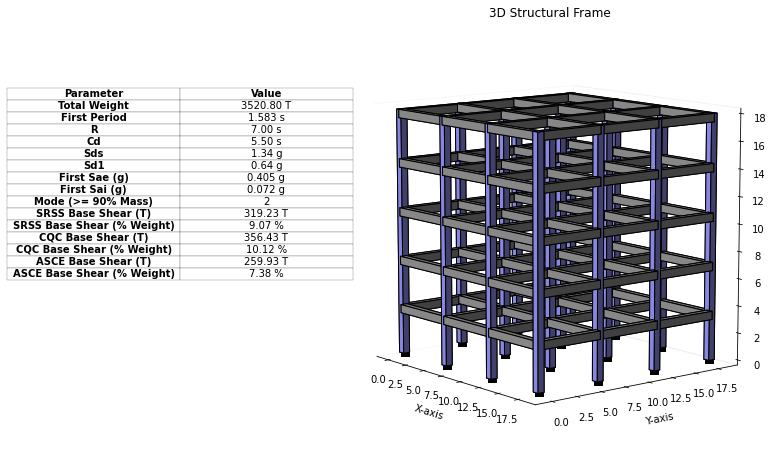

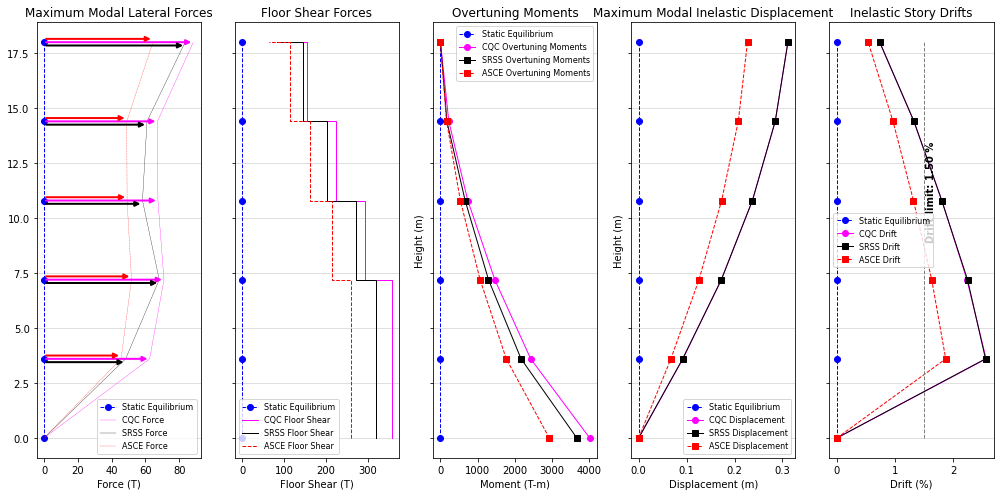

,Height,CQC of maximum modal lateral force [T],SRSS of maximum modal lateral force [T],ASCE of maximum modal lateral force [T],CQC Floor Shear Force [T],SRSS Floor Shear Force [T],ASCE Floor Shear Force [T],CQC Overturning Moment [T·m],SRSS Overturning Moment [T·m],ASCE Overturning Moment [T·m],CQC of maximum modal inelastic displacement [m],SRSS of maximum modal inelastic displacement [m],ASCE of maximum modal inelastic displacement [m],SRSS inelastic drift [ % ],CQC inelastic drift [ % ],ASCE inelastic drift [ % ]
0,0.0,0.000000,0.000000,0.000000,356.433607,319.229267,259.932214,4021.799095,3674.990424,2932.930906,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,3.6,62.510382,48.301593,45.586223,356.433607,319.229267,259.932214,2431.267090,2172.077422,1773.022028,0.092172,0.091785,0.067217,2.549589,2.560329,1.867142
2,7.2,70.988928,68.194711,51.769274,293.923226,270.927674,214.345991,1464.314202,1294.391141,1067.863480,0.172492,0.172462,0.125791,2.241034,2.231122,1.627065
3,10.8,67.421903,58.287360,49.167991,222.934298,202.732963,162.576717,736.157655,664.887655,536.849178,0.237335,0.237217,0.173079,1.798743,1.801198,1.313539
4,14.4,67.149506,60.950436,48.969344,155.512395,144.445603,113.408726,225.037375,173.885736,164.110403,0.284879,0.284831,0.207750,1.322606,1.320647,0.963093
5,18.0,88.362889,83.495167,64.439382,88.362889,83.495167,64.439382,0.000000,0.000000,0.000000,0.311350,0.311286,0.227054,0.734852,0.735310,0.536231


In [23]:
TieF = T
from mpl_toolkits.mplot3d import Axes3D                                                                                          # Import Axes3D for 3D plotting
first_period = TieF[0]                                                                                                           # Extract the first natural period (T1) from the period array
first_SaeF = SaeF[0]                                                                                                             # Extract the first (Sai) from the period array
first_SaiF = SaiF[0]                                                                                                             # Extract the first (Sae) from the period array
mode_90_mass = threshold_modal_shape                                                                                             # Identify the mode number at which at least 90% of the mass participation is reached

SRSS_base_shear_tons = VD_srss                                                                                                   # Assign the base shear obtained from SRSS combination in tons
SRSS_base_shear_percent = (SRSS_base_shear_tons / total_weight) * 100                                                            # Compute base shear as a percentage of total building weight

CQC_base_shear_tons = VD_cqc                                                                                                     # Assign the base shear obtained from CQC combination in tons
CQC_base_shear_percent = (CQC_base_shear_tons / total_weight) * 100                                                              # Compute base shear as a percentage of total building weight

ASCE_base_shear_tons = VD_ASCE                                                                                                   # Assign the base shear obtained from ASCE combination in tons
ASCE_base_shear_percent = (ASCE_base_shear_tons / total_weight) * 100                                                            # Compute base shear as a percentage of total building weight

def plot_3d_frame(sto, h, span, LV, total_weight, first_period, mode_90_mass, SRSS_base_shear_tons, SRSS_base_shear_percent,     # Define function to plot the 3D frame 
                  CQC_base_shear_tons, CQC_base_shear_percent , ASCE_base_shear_tons, ASCE_base_shear_percent,
                  first_SaeF, first_SaiF, R, Cd, Sds, Sd1):    
    alpha = 1                                                                                                                    # set value of alpha for column and beams transparency
    fig = plt.figure(figsize=(15, 8))                                                                                            # Create a figure with size 13x8
    ax = fig.add_subplot(111, projection='3d')                                                                                   # Add a 3D subplot for visualization

    x_positions = np.arange(0, (span[0] + 1) * LV, LV)                                                                           # X-coordinates for columns
    y_positions = np.arange(0, (span[1] + 1) * LV, LV)                                                                           # Y-coordinates for columns
    z_positions = np.arange(0, (sto + 1) * h, h)                                                                                 # Z-coordinates for floor levels

    # Draw columns
    for x in x_positions:                                                                                                        # Iterate over X positions
        for y in y_positions:                                                                                                    # Iterate over Y positions
            ax.plot([x, x], [y, y], [0, sto * h], color=(0, 0, 0), linewidth=2, linestyle = '--',                                # Draw vertical columns
                    marker='o', markerfacecolor=(1, 1, 1), markersize=1)                                                         # Add white circular markers at column top
            ax.bar3d(x - C/2, y - C/2, 0, C, C, sto * h, color=(0.6, 0.6, 1), alpha= alpha, shade=True, edgecolor=(0, 0, 0))     # Draw cuboid at column position                                                                 
            ax.plot([x, x], [y, y], [0, 0], color=(0, 0, 0), linewidth=1.0,                                                      # Draw base nodes
                    marker='s', markerfacecolor=(0, 0, 0), markersize=8)                                                         # Add black square markers at column base

    # Draw beams
    for z in z_positions[1:]:                                                                                                    # Iterate over floors (excluding base level)
        for x in x_positions:                                                                                                    # Iterate over X positions
            ax.plot([x, x], [y_positions[0], y_positions[-1]], [z, z], color=(0, 0, 0), linewidth=1.0,                           # Draw beams in Y direction
                    marker='o', markerfacecolor=(1, 1, 1), markersize=1)                                                         # Add white circular markers at beam junctions
        for y in y_positions:                                                                                                    # Iterate over Y positions
            ax.plot([x_positions[0], x_positions[-1]], [y, y], [z, z], color=(0, 0, 0), linewidth=1.0,                           # Draw beams in X direction
                    marker='o', markerfacecolor=(1, 1, 1), markersize=1)                                                         # Add white circular markers at beam junctions
    # Draw beams as solid
    for z in z_positions[1:]:                                                                                                    # Iterate over floors (excluding base level)
        for y in y_positions:                                                                                                    # Iterate over Y positions
            for x in x_positions[:-1]:                                                                                           # Iterate over X positions (excluding last to prevent out-of-bounds)
                ax.bar3d(x, y - C/2, z - C, LV, C, C, color=(0.6, 0.6, 0.6), alpha= alpha, shade=True, edgecolor=(0, 0, 0))      # Draw beams in X direction
        for x in x_positions:                                                                                                    # Iterate over X positions
            for y in y_positions[:-1]:                                                                                           # Iterate over Y positions (excluding last to prevent out-of-bounds)
                ax.bar3d(x - C/2, y, z - C, C, LV, C, color=(0.6, 0.6, 0.6), alpha= alpha, shade=True, edgecolor=(0, 0, 0))      # Draw beams in Y direction



    # Labels and formatting
    ax.view_init(elev=10, azim=-39)                                                                                              # Set the view angle (elevation and azimuth)
    ax.grid(False)                                                                                                               # Disable grid for better visualization
    ax.xaxis.pane.fill = False                                                                                                   # Remove background fill for X-plane
    ax.yaxis.pane.fill = False                                                                                                   # Remove background fill for Y-plane
    ax.zaxis.pane.fill = False                                                                                                   # Remove background fill for Z-plane
    ax.set_xlabel("X-axis", rotation=0, fontsize=10)                                                                             # Set X-axis label
    ax.set_ylabel("Y-axis", rotation=0, fontsize=10)                                                                             # Set Y-axis label
    ax.set_zlabel("Height (Z)", rotation=0, fontsize=10)                                                                         # Set Z-axis label
    ax.set_title("3D Structural Frame")                                                                                          # Set the title of the plot
    ax.set_box_aspect([max(x_positions) / max(z_positions), 
                   max(y_positions) / max(z_positions), 
                   1])                                                                                                           # Adjust aspect ratio to maintain proportionality between X, Y, and Z axes

    # Add table with key structural parameters
    table_data = [["Total Weight", f"{total_weight:.2f} T"],
                  ["First Period", f"{first_period:.3f} s"],
                  ["R", f"{R:.2f} s"],
                  ["Cd", f"{Cd:.2f} s"],
                  ["Sds", f"{Sds:.2f} g"],
                  ["Sd1", f"{Sd1:.2f} g"],
                  ["First Sae (g)", f"{first_SaeF:.3f} g"],
                  ["First Sai (g)", f"{first_SaiF:.3f} g"],
                  ["Mode (>= 90% Mass)", f"{mode_90_mass}"],
                  ["SRSS Base Shear (T)", f"{SRSS_base_shear_tons:.2f} T"],
                  ["SRSS Base Shear (% Weight)", f"{SRSS_base_shear_percent:.2f} %"],
                  ["CQC Base Shear (T)", f"{CQC_base_shear_tons:.2f} T"],
                  ["CQC Base Shear (% Weight)", f"{CQC_base_shear_percent:.2f} %"],
                  ["ASCE Base Shear (T)", f"{ASCE_base_shear_tons:.2f} T"],
                  ["ASCE Base Shear (% Weight)", f"{ASCE_base_shear_percent:.2f} %"]]
    
    ax_table = fig.add_axes([0.01, 0.50, 0.32, 0.2])                                                                             # Adjusted table position to avoid overlap
    ax_table.axis("off")                                                                                                         # Hide axis for the table
    table = ax_table.table(cellText=table_data, colLabels=["Parameter", "Value"], cellLoc="center", loc="center")                # Create table
    table.auto_set_font_size(False)                                                                                              # Disable automatic font resizing
    table.set_fontsize(10)                                                                                                       # Set font size
    table.scale(1.0, 1.0)                                                                                                        # Scale the table for better readability
    
    for key, cell in table.get_celld().items():
        cell.set_linewidth(0.2)                                                                                                  # Make gridlines thinner
        if key[0] == 0 or key[1] == 0:
            cell.set_text_props(fontweight='bold')                                                                               # Make headers bold
    
    plt.show()                                                                                                                   # Display the plot

plot_3d_frame(sto, h, span, LV, total_weight, first_period, mode_90_mass, SRSS_base_shear_tons, SRSS_base_shear_percent,     
                  CQC_base_shear_tons, CQC_base_shear_percent , ASCE_base_shear_tons, ASCE_base_shear_percent,
                  first_SaeF, first_SaiF, R, Cd, Sds, Sd1)



# Function to plot the summary of the results
def plot_summary_subplots(Summary, maxdrift):                                                                                    # Define the function with Summary DataFrame and max drift limit
    fig, axes = plt.subplots(1, 5, figsize=(14, 7), sharey=True)                                                                 # Create 4 subplots in one row with shared Y-axis (height)

    # First subplot: Maximum Modal Lateral Forces
    axes[0].plot(np.zeros(len(Summary["Height"])), Summary["Height"], marker='o', markerfacecolor=(0, 0, 1),                     # Plot static equilibrium (vertical reference)
                 linestyle='--', color=(0, 0, 1), linewidth=1.0, label="Static Equilibrium")
    axes[0].plot(Summary["CQC of maximum modal lateral force [T]"], Summary["Height"],                                           # Plot CQC modal force vs height
                 linestyle='-', color=(1, 0, 1), linewidth=0.3, label="CQC Force")  
    axes[0].plot(Summary["SRSS of maximum modal lateral force [T]"], Summary["Height"],                                          # Plot SRSS modal force vs height
                 linestyle='-', color=(0, 0, 0), linewidth=0.3, label="SRSS Force")
    axes[0].plot(Summary["ASCE of maximum modal lateral force [T]"], Summary["Height"],                                          # Plot ASCE modal force vs height
                 linestyle='--', color=(1, 0, 0), linewidth=0.3, label="ASCE Force")    
    axes[0].set_xlabel("Force (T)", fontsize=10)                                                                                 # Set X-axis label
    axes[0].set_title("Maximum Modal Lateral Forces", fontsize=12)                                                               # Set subplot title
    axes[0].legend(fontsize=8)                                                                                                   # Add legend
    axes[0].grid(which='both', axis='y', alpha=0.5)                                                                              # Enable grid for better visualization

    # Add proportional arrows for forces CQC (Magenta)
    for i in range(len(Summary["Height"])):                                                                                      # Loop through each floor height
        force_value = Summary["CQC of maximum modal lateral force [T]"].iloc[i]                                                  # Get force value at each floor
        axes[0].annotate("", xy=(force_value, Summary["Height"].iloc[i]), xytext=(0, Summary["Height"].iloc[i]),                 # Draw force arrow
                        arrowprops=dict(facecolor=(1, 0, 1), edgecolor=(1, 0, 1), 
                                        arrowstyle='-|>', lw=2.0, alpha=1.0))

    # Add proportional arrows for forces SRSS (Black, shifted slightly down)
    for i in range(len(Summary["Height"])):                                                                                      # Loop through each floor height
        force_value = Summary["SRSS of maximum modal lateral force [T]"].iloc[i]                                                 # Get force value at each floor
        axes[0].annotate("", xy=(force_value, Summary["Height"].iloc[i] - 0.15), xytext=(0, Summary["Height"].iloc[i] - 0.15),   # Draw force arrow (shifted down)
                        arrowprops=dict(facecolor=(0, 0, 0), edgecolor=(0, 0, 0), 
                                        arrowstyle='-|>', lw=2.0, alpha=1.0))
    
    # Add proportional arrows for forces ASCE (Red, shifted slightly up)
    for i in range(len(Summary["Height"])):                                                                                      # Loop through each floor height
        force_value = Summary["ASCE of maximum modal lateral force [T]"].iloc[i]                                                 # Get force value at each floor
        axes[0].annotate("", xy=(force_value, Summary["Height"].iloc[i] + 0.15), xytext=(0, Summary["Height"].iloc[i] + 0.15),   # Draw force arrow (shifted down)
                        arrowprops=dict(facecolor=(1, 0, 0), edgecolor=(1, 0, 0), 
                                        arrowstyle='-|>', lw=2.0, alpha=1.0))

    # Second subplot: Floor Shear Forces (Stepped Plot)
    axes[1].plot(np.zeros(len(Summary["Height"])), Summary["Height"], marker='o', markerfacecolor=(0, 0, 1),                     # Plot static equilibrium (vertical reference)
                 linestyle='--', color=(0, 0, 1), linewidth=1.0, label="Static Equilibrium")
    axes[1].step(Summary["CQC Floor Shear Force [T]"], Summary["Height"], where='pre',                                           # Step plot for CQC shear force
                 linestyle='-', color=(1, 0, 1), linewidth=1.0, label="CQC Floor Shear")  
    axes[1].step(Summary["SRSS Floor Shear Force [T]"], Summary["Height"], where='pre',                                          # Step plot for SRSS shear force
                 linestyle='-', color=(0, 0, 0), linewidth=1.0, label="SRSS Floor Shear")
    axes[1].step(Summary["ASCE Floor Shear Force [T]"], Summary["Height"], where='pre',                                          # Step plot for ASCE shear force
                 linestyle='--', color=(1, 0, 0), linewidth=1.0, label="ASCE Floor Shear")  
    axes[1].set_xlabel("Floor Shear (T)", fontsize=10)                                                                           # Set X-axis label
    axes[1].set_title("Floor Shear Forces", fontsize=12)                                                                         # Set subplot title
    axes[1].legend(fontsize=8)                                                                                                   # Add legend
    axes[1].grid(which='both', axis='y', alpha=0.5)                                                                              # Enable grid for better visualization
    
    # Third subplot: Maximum Modal Inelastic Displacement
    axes[2].plot(np.zeros(len(Summary["Height"])), Summary["Height"], marker='o', markerfacecolor=(0, 0, 1),                     # Plot static equilibrium (vertical reference)
                 linestyle='--', color=(0, 0, 1), linewidth=1.0, label="Static Equilibrium")
    axes[2].plot(Summary["CQC Overturning Moment [T·m]"], Summary["Height"],                                                     # Plot CQC overtuning moments vs height
                 marker='o', linestyle='-', color=(1, 0, 1), linewidth=1.0, label="CQC Overtuning Moments")  
    axes[2].plot(Summary["SRSS Overturning Moment [T·m]"], Summary["Height"],                                                    # Plot SRSS overtuning moments vs height
                 marker='s', linestyle='-', color=(0, 0, 0), linewidth=1.0, label="SRSS Overtuning Moments")
    axes[2].plot(Summary["ASCE Overturning Moment [T·m]"], Summary["Height"],                                                    # Plot ASCE overtuning moments vs height
                 marker='s', linestyle='--', color=(1, 0, 0), linewidth=1.0, label="ASCE Overtuning Moments")   
    axes[2].set_ylabel("Height (m)", fontsize=10)                                                                                # Set Y-axis label
    axes[2].set_xlabel("Moment (T-m)", fontsize=10)                                                                              # Set X-axis label
    axes[2].set_title("Overtuning Moments", fontsize=12)                                                                         # Set subplot title
    axes[2].legend(fontsize=8)                                                                                                   # Add legend
    axes[2].grid(which='both', axis='y', alpha=0.5)                                                                              # Enable grid for better visualization

    # Fourth subplot: Maximum Modal Inelastic Displacement
    axes[3].plot(np.zeros(len(Summary["Height"])), Summary["Height"], marker='o', markerfacecolor=(0, 0, 1),                     # Plot static equilibrium (vertical reference)
                 linestyle='--', color=(0, 0, 1), linewidth=1.0, label="Static Equilibrium")
    axes[3].plot(Summary["CQC of maximum modal inelastic displacement [m]"], Summary["Height"],                                  # Plot CQC modal displacement vs height
                 marker='o', linestyle='-', color=(1, 0, 1), linewidth=1.0, label="CQC Displacement")  
    axes[3].plot(Summary["SRSS of maximum modal inelastic displacement [m]"], Summary["Height"],                                 # Plot SRSS modal displacement vs height
                 marker='s', linestyle='-', color=(0, 0, 0), linewidth=1.0, label="SRSS Displacement")
    axes[3].plot(Summary["ASCE of maximum modal inelastic displacement [m]"], Summary["Height"],                                 # Plot ASCE modal displacement vs height
                 marker='s', linestyle='--', color=(1, 0, 0), linewidth=1.0, label="ASCE Displacement")  
    axes[3].set_ylabel("Height (m)", fontsize=10)                                                                                # Set Y-axis label
    axes[3].set_xlabel("Displacement (m)", fontsize=10)                                                                          # Set X-axis label
    axes[3].set_title("Maximum Modal Inelastic Displacement", fontsize=12)                                                       # Set subplot title
    axes[3].legend(fontsize=8)                                                                                                   # Add legend
    axes[3].grid(which='both', axis='y', alpha=0.5)                                                                              # Enable grid for better visualization

    # Fifth subplot: Inelastic Story Drifts
    axes[4].plot(np.zeros(len(Summary["Height"])), Summary["Height"], marker='o', markerfacecolor=(0, 0, 1),                     # Plot static equilibrium (vertical reference)
                 linestyle='--', color=(0, 0, 1), linewidth=1.0, label="Static Equilibrium")
    axes[4].plot(Summary["CQC inelastic drift [ % ]"], Summary["Height"],                                                        # Plot CQC inelastic drift vs height
                 marker='o', linestyle='-', color=(1, 0, 1), linewidth=1.0, label="CQC Drift")  
    axes[4].plot(Summary["SRSS inelastic drift [ % ]"], Summary["Height"],                                                       # Plot SRSS inelastic drift vs height
                 marker='s', linestyle='-', color=(0, 0, 0), linewidth=1.0, label="SRSS Drift")
    axes[4].plot(Summary["ASCE inelastic drift [ % ]"], Summary["Height"],                                                       # Plot SRSS inelastic drift vs height
                 marker='s', linestyle='--', color=(1, 0, 0), linewidth=1.0, label="ASCE Drift")  
    axes[4].plot(np.ones(len(Summary["Height"])) * maxdrift, Summary["Height"],                                                  # Plot horizontal line for drift limit
                linestyle='--', color=(0.5, 0.5, 0.5), linewidth=1.0)
    axes[4].text(maxdrift * 1.02, H_cumulative[-1] / 2, f'Drift limit: {maxdrift:.2f} %',                                        # Add vertical text annotation for drift limit 
                 rotation=90, ha='left', fontsize=10, fontweight='bold')                
    axes[4].set_xlabel("Drift (%)", fontsize=10)                                                                                 # Set X-axis label
    axes[4].set_title("Inelastic Story Drifts", fontsize=12)                                                                     # Set subplot title
    axes[4].legend(fontsize=8)                                                                                                   # Add legend
    axes[4].grid(which='both', axis='y', alpha=0.5)                                                                              # Enable grid for better visualization

    plt.tight_layout()                                                                                                           # Adjust layout to prevent overlap
    plt.show()                                                                                                                   # Display the plot

# Call the function with the Summary DataFrame
plot_summary_subplots(Summary, maxdrift)                                                                                         # Execute the function
Summary.head(len(ds_CQC))                                                                                                        # Display all rows of the dataset